# EfficientNet Binary Classification

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import os
import json
import joblib

from torch.utils.data import DataLoader, Dataset
import torch.utils.data as utils
from torchvision import transforms

import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision
from loguru import logger

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from efficientnet_pytorch import EfficientNet
from early_stopping_pytorch import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score

from nazi_symbols_classification.training.data_preparation import get_image_paths, load_labels_df
from nazi_symbols_classification.training.torch_dataset_preparation import ImageData, get_device, to_device, ToDeviceLoader
%matplotlib inline

## Data Preparation

Load the dataset and prepare it for training. The dataset is expected to be in a specific directory structure.
then we create PyTorch DataLoader objects for training, validation, and testing datasets.

In [3]:
dir_name = os.path.dirname(os.getcwd())
dataset_path = f"{dir_name}/datasets/nazi-symbols-detection"

In [5]:
train_labels_df = load_labels_df(dataset_path, "train", binary=True)
valid_labels_df = load_labels_df(dataset_path, "val", binary=True)
test_labels_df = load_labels_df(dataset_path, "test", binary=True)

2025-06-14 21:53:05.422 | INFO     | __main__:load_labels_df:3 - Number of images in train is 75369
2025-06-14 21:53:05.451 | INFO     | __main__:load_labels_df:3 - Number of images in val is 15376
2025-06-14 21:53:05.466 | INFO     | __main__:load_labels_df:3 - Number of images in test is 15018


In [6]:
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((224, 224)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize((0.5,), (0.5,))])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf,
                           label_column="contained_nazi")
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf,
                           label_column="contained_nazi")
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf,
                           label_column="contained_nazi")
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [8]:
batch_size = 48

train_loader, valid_loader, test_loader = create_datasets(batch_size, dataset_path)

Device Preparation

In [ ]:
device = get_device()
print(device)

train_dl = ToDeviceLoader(train_loader, device)
valid_dl = ToDeviceLoader(valid_loader, device)
test_dl = ToDeviceLoader(test_loader, device)

### Data Sanity Check

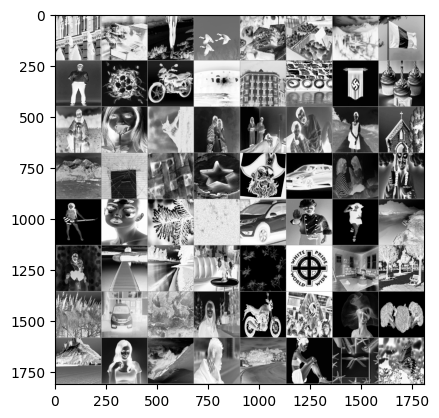

In [9]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

## Model Preparation

In [10]:
model = EfficientNet.from_name('efficientnet-b2', num_classes=2)

Unfreezing model weights

In [11]:
for param in model.parameters():
    param.requires_grad = True

Changing the final layer to output a single value for binary classification

In [12]:
num_ftrs = model._fc.in_features
model._fc = nn.Linear(num_ftrs, 1)

In [13]:
model = model.to(device)

In [14]:
optimizer = optim.NAdam(model.parameters(),lr=0.00002)

In [15]:
loss_fn = nn.BCELoss()

Define the training function

In [16]:
def train_model(model, patience, n_epochs):
    
    # to track the training loss as the model trains
    train_losses = []
    # to track the validation loss as the model trains
    valid_losses = []
    # to track the average training loss per epoch as the model trains
    avg_train_losses = []
    # to track the average validation loss per epoch as the model trains
    avg_valid_losses = [] 
    
    # initialize the early_stopping object
    early_stopping = EarlyStopping(patience=patience, verbose=True, path="efficientnet-output/efficientnet-b2-binary-pretrained-size-224-batch-48.pt")
    
    for epoch in range(n_epochs):

        ###################
        # train the model #
        ###################
        model.train() # prep model for training
        for i, (data, target) in enumerate(train_dl):
            # Every data instance is an input + label pair
            target = target.float()                
            target = target.unsqueeze(1)
    
            # Zero your gradients for every batch!
            optimizer.zero_grad()
    
            # Make predictions for this batch
            output = model(data)
            m = nn.Sigmoid()
    
            # Compute the loss and its gradients
            loss = loss_fn(m(output), target)
            loss.backward()
    
            # Adjust learning weights
            optimizer.step()
            # record training loss
            train_losses.append(loss.item())

        ######################    
        # validate the model #
        ######################
        model.eval() # prep model for evaluation
        for data, target in valid_dl:
            target = target.float()                
            target = target.unsqueeze(1)
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            m = nn.Sigmoid()
            # calculate the loss
            loss = loss_fn(m(output), target)
            # record validation loss
            valid_losses.append(loss.item())

        # print training/validation statistics 
        # calculate average loss over an epoch
        train_loss = np.average(train_losses)
        valid_loss = np.average(valid_losses)
        avg_train_losses.append(train_loss)
        avg_valid_losses.append(valid_loss)
        
        epoch_len = len(str(n_epochs))
        
        print_msg = (f'[{(epoch + 1):>{epoch_len}}/{(n_epochs + 1):>{epoch_len}}] ' +
                     f'train_loss: {train_loss:.5f} ' +
                     f'valid_loss: {valid_loss:.5f}')
        
        print(print_msg)
        
        # clear lists to track next epoch
        train_losses = []
        valid_losses = []
        
        # early_stopping needs the validation loss to check if it has decresed, 
        # and if it has, it will make a checkpoint of the current model
        early_stopping(valid_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    # load the last checkpoint with the best model
    model.load_state_dict(torch.load('efficientnet-output/efficientnet-b2-binary-pretrained-size-224-batch-48.pt', weights_only=True))

    return  model, avg_train_losses, avg_valid_losses

## Training the Model

In [ ]:
%%time
# Training model for 5 epochs and logging the time required for the entire training process
# Initializing in a separate cell so we can easily add more epochs to the same run
n_epochs = 100

# early stopping patience; how long to wait after last time validation loss improved.
patience = 10

model, train_loss, valid_loss = train_model(model, patience, n_epochs)

[  1/101] train_loss: 0.14052 valid_loss: 0.11201
Validation loss decreased (inf --> 0.112005).  Saving model ...
[  2/101] train_loss: 0.09759 valid_loss: 0.04625
Validation loss decreased (0.112005 --> 0.046250).  Saving model ...
[  3/101] train_loss: 0.08347 valid_loss: 0.03050
Validation loss decreased (0.046250 --> 0.030498).  Saving model ...
[  4/101] train_loss: 0.07376 valid_loss: 0.02822
Validation loss decreased (0.030498 --> 0.028222).  Saving model ...
[  5/101] train_loss: 0.06860 valid_loss: 0.02331
Validation loss decreased (0.028222 --> 0.023312).  Saving model ...
[  6/101] train_loss: 0.06578 valid_loss: 0.02121
Validation loss decreased (0.023312 --> 0.021207).  Saving model ...
[  7/101] train_loss: 0.06124 valid_loss: 0.02437
EarlyStopping counter: 1 out of 10
[  8/101] train_loss: 0.05958 valid_loss: 0.02574
EarlyStopping counter: 2 out of 10
[  9/101] train_loss: 0.05781 valid_loss: 0.02916
EarlyStopping counter: 3 out of 10
[ 10/101] train_loss: 0.05548 valid_

In [19]:
history = dict(train_loss=train_loss, valid_loss=valid_loss)
with open('efficientnet-output/efficientnet-binary-pretrained-history.json', 'w') as f:
    f.write(json.dumps(history))

## Evaluating the Model

In [17]:
model.load_state_dict(torch.load('efficientnet-output/efficientnet-b2-binary-pretrained-size-224-batch-48.pt', weights_only=True))
model.eval()

EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    

Evaluating the model on the test dataset. The model outputs are converted to probabilities using the sigmoid function, and predictions are made based on a threshold of 0.5.

In [18]:
outputs = []
y_true = []
probabilities = []
out = None
for images, labels in test_dl:
    with torch.no_grad():
        output = model(images)
    pred = torch.sigmoid(output)
    predicted_vals = pred > 0.5
    y_true += to_device(labels, "cpu")
    outputs += to_device(predicted_vals, "cpu")
    probabilities += to_device(pred, "cpu")

In [19]:
len(probabilities)

15018

Convert outputs and labels to lists of integers for evaluation metrics. Then diaplay the classification report and calculate the probabilities for ROC and PR curves.

In [20]:
outputs = [int(out) for out in outputs]

probs = []
for prob in probabilities:
    probs.append(prob.detach().item())

fpr, tpr, roc_threshold = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)
precision, recall, pr_threshold = precision_recall_curve(y_true, probs)
average_precision = average_precision_score(y_true, probs)
roc_auc_result = dict(precision=precision, recall=recall, pr_threshold=pr_threshold, average_precision=average_precision,
                      fpr=fpr, tpr=tpr, roc_threshold=roc_threshold, roc_auc=roc_auc)

print(classification_report(y_true, outputs, digits=3))
print("accuracy score:", accuracy_score(y_true, outputs))
print("roc auc score:", roc_auc_score(y_true, outputs))

              precision    recall  f1-score   support

           0      0.997     0.997     0.997     14813
           1      0.772     0.761     0.767       205

    accuracy                          0.994     15018
   macro avg      0.884     0.879     0.882     15018
weighted avg      0.994     0.994     0.994     15018

accuracy score: 0.9936742575575975
roc auc score: 0.8789351146734987


saving the ROC AUC results and predicted results to joblib files for plotting

In [21]:
predicted_result = dict(y_true=y_true, probs=probs, outputs=outputs)

joblib.dump(roc_auc_result, 'efficientnet-output/efficientnet-binary-pretrained-roc-auc-results.joblib')
joblib.dump(predicted_result, 'efficientnet-output/efficientnet-binary-pretrained-predicted-results.joblib')

['efficientnet-output/efficientnet-binary-pretrained-predicted-results.joblib']